# Fixed Effects Panel Regression

## linearmodels PanelOLS

## Imports

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.formula.api as smf

plt.rcParams["figure.figsize"] = (8, 4.5)


## Make fake panel data (countries × years)

In [ ]:
rng = np.random.default_rng(0)

countries = ["DNK", "SWE", "NOR", "DEU", "FRA", "NLD", "ESP", "ITA"]
years = np.arange(2000, 2016)

df = pd.MultiIndex.from_product([countries, years], names=["country", "year"]).to_frame(index=False)

# Regressors
df["x1"] = rng.normal(size=len(df))
df["x2"] = rng.normal(size=len(df))

# True fixed effects
country_fe = {c: rng.normal(0, 1.0) for c in countries}
year_fe = {y: rng.normal(0, 0.6) for y in years}

# Outcome generated by a two-way FE DGP
df["y"] = (
    1.0
    + 0.7 * df["x1"]
    - 0.2 * df["x2"]
    + df["country"].map(country_fe)
    + df["year"].map(year_fe)
    + rng.normal(0, 1.0, size=len(df))
)

df.head()

,country,year,x1,x2,y
0,DNK,2000,0.125730,-0.568549,0.982194
1,DNK,2001,-0.132105,-1.029804,0.531906
2,DNK,2002,0.640423,-1.043001,0.402256
3,DNK,2003,0.104900,0.268417,-0.288935
4,DNK,2004,-0.535669,0.358672,-3.900329


## Quick sanity plot (mean y by year)

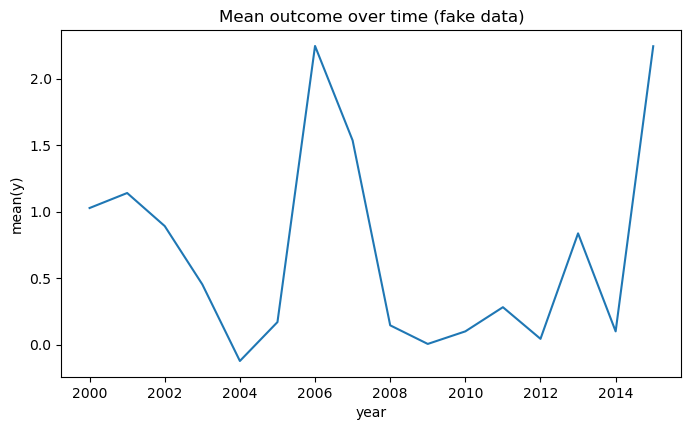

In [5]:
mean_by_year = df.groupby("year")["y"].mean()

plt.figure()
plt.plot(mean_by_year.index, mean_by_year.values)
plt.xlabel("year")
plt.ylabel("mean(y)")
plt.title("Mean outcome over time (fake data)")
plt.show()


## Two-way FE with statsmodels (dummy FE)

In [6]:
res_sm = smf.ols(
    "y ~ x1 + x2 + C(country) + C(year)",
    data=df
).fit(
    cov_type="cluster",
    cov_kwds={"groups": df["country"]}  # cluster by country (common)
)

print(res_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.724
Model:                            OLS   Adj. R-squared:                  0.660
Method:                 Least Squares   F-statistic:                     2.788
Date:                Thu, 05 Feb 2026   Prob (F-statistic):             0.0998
Time:                        21:28:29   Log-Likelihood:                -169.71
No. Observations:                 128   AIC:                             389.4
Df Residuals:                     103   BIC:                             460.7
Df Model:                          24                                         
Covariance Type:              cluster                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             3.4023      0.36

c:\Users\Anton\anaconda3\Lib\site-packages\statsmodels\base\model.py:1888: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 24, but rank is 7
  warnings.warn('covariance of constraints does not have full '


## Extract the main coefficients (statsmodels)

In [7]:
print("Statsmodels estimates:")
print("beta_x1 =", res_sm.params["x1"])
print("beta_x2 =", res_sm.params["x2"])
print("\nClustered SEs (by country):")
print("se_x1 =", res_sm.bse["x1"])
print("se_x2 =", res_sm.bse["x2"])


Statsmodels estimates:
beta_x1 = 0.6895481344173343
beta_x2 = -0.25391773985955696

Clustered SEs (by country):
se_x1 = 0.08215897386664098
se_x2 = 0.061920385727000836


## Method 2 - Two-way FE with linearmodels PanelOLS (recommended)

In [9]:
# PanelOLS wants a MultiIndex (entity, time)
df_panel = df.set_index(["country", "year"]).sort_index()

mod = PanelOLS.from_formula(
    "y ~ 1 + x1 + x2 + EntityEffects + TimeEffects",
    data=df_panel
)

# Clustered SEs by country (entity)
res_lm = mod.fit(cov_type="clustered", cluster_entity=True)
print(res_lm.summary)


                          PanelOLS Estimation Summary                           
Dep. Variable:                      y   R-squared:                        0.3300
Estimator:                   PanelOLS   R-squared (Between):              0.1161
No. Observations:                 128   R-squared (Within):               0.3060
Date:                Thu, Feb 05 2026   R-squared (Overall):              0.2295
Time:                        21:30:13   Log-likelihood                   -169.71
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      25.360
Entities:                           8   P-value                           0.0000
Avg Obs:                       16.000   Distribution:                   F(2,103)
Min Obs:                       16.000                                           
Max Obs:                       16.000   F-statistic (robust):             46.221
                            

## Optional: two-way clustered SEs (country + year)

In [10]:
res_lm_2way = mod.fit(cov_type="clustered", cluster_entity=True, cluster_time=True)
print(res_lm_2way.summary)


                          PanelOLS Estimation Summary                           
Dep. Variable:                      y   R-squared:                        0.3300
Estimator:                   PanelOLS   R-squared (Between):              0.1161
No. Observations:                 128   R-squared (Within):               0.3060
Date:                Thu, Feb 05 2026   R-squared (Overall):              0.2295
Time:                        21:30:23   Log-likelihood                   -169.71
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      25.360
Entities:                           8   P-value                           0.0000
Avg Obs:                       16.000   Distribution:                   F(2,103)
Min Obs:                       16.000                                           
Max Obs:                       16.000   F-statistic (robust):             59.974
                            

c:\Users\Anton\anaconda3\Lib\site-packages\linearmodels\panel\results.py:88: RuntimeWarning: invalid value encountered in sqrt
  return Series(np.sqrt(np.diag(self.cov)), self._var_names, name="std_error")


## Comparison

In [11]:
comparison = pd.DataFrame({
    "statsmodels_coef": [res_sm.params["x1"], res_sm.params["x2"]],
    "statsmodels_se_clust_country": [res_sm.bse["x1"], res_sm.bse["x2"]],
    "linearmodels_coef": [res_lm.params["x1"], res_lm.params["x2"]],
    "linearmodels_se_clust_country": [res_lm.std_errors["x1"], res_lm.std_errors["x2"]],
}, index=["x1", "x2"])

comparison


,statsmodels_coef,statsmodels_se_clust_country,linearmodels_coef,linearmodels_se_clust_country
x1,0.689548,0.082159,0.689548,0.077155
x2,-0.253918,0.061920,-0.253918,0.058149
